# 상환중인 고객 데이터로 모델 예측하기
- 원본 데이터에 저장되어 있는 loan_status == 'Current' (상환중) 상태인 차주들을 대상으로 부도 예측 모델 적용

## 모듈 불러오기

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
warnings.filterwarnings('ignore')
import joblib

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

# 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


print("=" * 60)
print("로드 완료")
print("=" * 60)

로드 완료


In [3]:
# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

## 데이터 불러오기 및 작업용 데이터셋 생성

In [4]:
# 원본 데이터 불러오기
df = pd.read_csv("data/accepted_2007_to_2018Q4.csv")

In [5]:
# curent 예측용 데이터 프레임 생성
current = df.copy()

### 모델과 동일한 피처 추출, curent 상태인 것만 추출

In [6]:
# current 상태 추출
current = current[current["loan_status"]=='Current']

In [7]:
# 파생변수 생성 -----> target 변수를 제외한 나머지 전처리 동일하게 진행

# 파생변수 1.종속변수(target) 생성 <--- 필요없음
# status_map = { 
#     "Fully Paid" : 0 ,
#     "Charged Off" :1, 
#     "Default" : 1
# }
# current["target"] = current["loan_status"].map(status_map)
# current = current[current["target"].notnull()]


# 파생변수 2. 날짜형 변수 년, 월 단위 변수(issue_year, issue_month) 생성 
current['issue_d'] = pd.to_datetime(current['issue_d'], errors="coerce") # 변수(issue_d)를 날짜형으로 변환
current['issue_year'] = current['issue_d'].dt.year.astype(str) # str 타입으로 저장 --> 모델링에 사용할 때 문자형으로 입력 예정
current['issue_month'] = current['issue_d'].dt.month.astype(str) # str 타입으로 저장 --> 모델링에 사용할 때 문자형으로 입력 예정

# 파생변수 3. 월 상환 부담율(installment_to_income) 생성
current['installment_to_income'] = current['installment'] / (current['annual_inc'] / 12)

# 파생변수 4. 대출규모 대비 소득(loan_to_income) 생성
current['loan_to_income'] = current['loan_amnt'] / current['annual_inc']

# 파생변수 5. 회전부채 대비 소득(revol_bal_to_income) 생성
current['revol_bal_to_income'] = current['revol_bal'] / current['annual_inc'] 

# 파생변수 6. 대출 당시 신용 조회 평균 (fico_mid)
current['fico_mid'] = (current['fico_range_low'] + current['fico_range_high'])/2

# 파생변수 7. 신용 조회 컬럼 플래그 생성 (mths_since_last_major_derog_missing, mths_since_recent_inq)
# 결측이라면 연체가 없다는 의미
cols = [
'mths_since_last_delinq',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_recent_inq',
'mths_since_recent_bc'
]
for col in cols:
    current[col+"_flag"] = current[col].isna().astype(int) # 결측값일때 1 아닐때 0, 1이라는 것은 연체가 없다는 것 


# 숫자 잘못 처리 되었을 때 NaN 처리 (분모가 0일 때 inf값 생성 가능성 있음)
new_cols = ['installment_to_income', 'loan_to_income','revol_bal_to_income']
for col in new_cols:
    current[col] = current[col].replace([np.inf, -np.inf], np.nan)

In [8]:
# 행제거

# 변경된 정책을 반영하여 행 제거
# 연도 자르기 
change_mask = "num_actv_bc_tl" # 연도를 자를 기준컬럼 변수 지정(활성 뱅크카드 수 컬럼)
current = current.dropna(subset=[change_mask])

# mo_sin_oldcurrentv_tl_op이 null인 행 제거 
current = current.dropna(subset=["mo_sin_old_rev_tl_op"]) # null 1
current = current.dropna(subset=["num_rev_accts"]) # null 1

# 전체 계좌 평균 잔액 ($) 이 null 인행 제거 
current = current.dropna(subset=["avg_cur_bal"])

### 결측치 처리

In [9]:
# 범주형 변수 처리
current["emp_length"] = current["emp_length"].fillna("unknown") # 근속 연수 결측치는  unknown 처리
current["home_ownership"] = current["home_ownership"].replace(["ANY","NONE"],"OTHER" ) # 주거 형태  OTHER 로 통합 

# 수치형 변수 처리
current["inq_last_6mths"] = current['inq_last_6mths'].fillna(0) #  최근 6개월간 신용 조회(hard inquiry) 횟수 결측치 1
current["revol_util"]= current["revol_util"].fillna(0) #리볼빙 이용률 (%) 
current["bc_open_to_buy"]= current["bc_open_to_buy"].fillna(0) #뱅크카드 잔여 한도 ($) 
current["bc_util"]= current["bc_util"].fillna(0) #뱅크카드 이용률 (%)
current["percent_bc_gt_75"]= current["percent_bc_gt_75"].fillna(0) #뱅크카드 75%인 뱅크카드 비율 (%)
current["mo_sin_old_il_acct"].fillna(0)
current["dti"] = current["dti"].replace(999, np.nan) # dti 변경전 >> 결측치 Null 로 변경
current.loc[current["dti"] < 0, "dti"] = np.nan  


### 미사용 컬럼 제거

In [10]:
# 미사용 컬럼 제거

"""
제거 대상 컬럼
"""
print(f"제거 작업 전 컬럼 수 : {len(current.columns)}개")

drop_columns = [
    # ── 그룹 1: 사후 상환 실적 ──
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',

    # ── 그룹 2: 잔액 사후 정보 ──
    'out_prncp', 'out_prncp_inv',

    # ── 그룹 3: 상각/추심 사후 ──
    'recoveries', 'collection_recovery_fee',

    # ── 그룹 4: 사후 신용 스냅샷 ──
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',

    # ── 그룹 5: Hardship / Settlement ──
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'orig_projected_additional_accrued_interest',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term',

    # ── 그룹 6: 특별 상환 계획 ──
    'pymnt_plan', 'payment_plan_start_date',

    # ── 그룹 7: 승인/집행 결과 ──
    'funded_amnt', 'funded_amnt_inv', 'disbursement_method',

    # ── 그룹 8: 식별자 및 상수 ──
    'id', 'member_id', 'url', 'title', 'zip_code', 'policy_code',

    # ── 그룹 9: 원본 타겟 변수 ──
    'loan_status',

    # ── 그룹 10: 효과 크기 낮은 변수 ── 후보 
    #'initial_list_status', 'total_acc', 'open_acc',
    #'application_type', 'addr_state', 'earliest_cr_line', 'pub_rec',

    # ── 그룹 11: 공동 신청(Joint) 관련 ──
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc',
    'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il',
    'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog',

    # 2016년 이후 신규 추가된 세부 신용 리포트 항목 (13개) 
    "open_acc_6m", "open_act_il", "open_il_12m", "open_il_24m","total_bal_il"
    ,"il_util","open_rv_12m","open_rv_24m","max_bal_bc","all_util","inq_fi" 
    ,"total_cu_tl", "inq_last_12m",

    # 3차 검토 사용 불가 판정 
    "desc", "emp_title", "num_tl_120dpd_2m", 
    
    # 모델에 사용하지 않는 컬럼 제거
    'grade', 'verification_status', 'addr_state', 'delinq_2yrs',
    'inq_last_6mths', 'mths_since_last_record', 'open_acc',
    'initial_list_status', 'collections_12_mths_ex_med', 'application_type',
    'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'bc_util',
    'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_rcnt_tl', 'mort_acc',
    'num_accts_ever_120_pd', 'num_bc_sats', 'num_bc_tl', 'num_op_rev_tl',
    'num_rev_accts', 'num_sats', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
    'tax_liens', 'total_bal_ex_mort', 'total_il_high_credit_limit', 'fico_range_low', 'fico_range_high'
]

# 중복 검증
assert len(drop_columns) == len(set(drop_columns)), \
    f"중복 존재: {[c for c in drop_columns if drop_columns.count(c) > 1]}"

# 실제 적용
current = current.drop(columns=[c for c in drop_columns if c in df.columns])

print(f"총 제거 대상: {len(drop_columns)}개")
print(f"남은 컬럼: {len(current.columns)}개")

제거 작업 전 컬럼 수 : 163개
총 제거 대상: 114개
남은 컬럼: 49개


### 결측값 처리

In [11]:
# 결측값 대체

# 파생변수 결측값 채우기
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income']
for col in new_cols:
    train_median = current[col].median()                   
    current[col] = current[col].fillna(train_median)       

# dti "sub_grade" 사용해야함 
current["dti"] = current.groupby("sub_grade")["dti"].transform(lambda x: x.fillna(x.median())
)
train_dit_medi = current.groupby("sub_grade")["dti"].median()

# 신용 조회, 
cols = [
'mths_since_last_delinq',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_recent_inq',
'mths_since_recent_bc',
'mths_since_rcnt_il',
'mo_sin_old_il_acct'
]
for col in cols:
    max_val = current[col].max()
    current[col] = current[col].fillna(max_val + 1)

# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 
medi_dlq = current["pct_tl_nvr_dlq"].median()
current["pct_tl_nvr_dlq"] = current["pct_tl_nvr_dlq"].fillna(medi_dlq)


### 예측용 데이터프레임 생성

In [12]:
predict_current = current.copy()

### 모델 불러오기

In [13]:
model_info = joblib.load("loan_default_model.joblib")

model = model_info["model"]
features = model_info["features"]
threshold = model_info["threshold"]

### 데이터를 부도 예측 모델에 적용

In [14]:
# 모델의 부도확률 예측
X_pred = predict_current[model_info["features"]].copy()

cat_idx = model.get_cat_feature_indices()
cat_cols = [X_pred.columns[i] for i in cat_idx]
for c in cat_cols:
    X_pred[c] = X_pred[c].astype(str)

proba = model.predict_proba(X_pred)[:, 1]

pred = (proba >= threshold).astype(int)

In [15]:
# 예측결과 데이터프레임에 붙이기
result = current.copy()

result["default_probability"] = proba
result["default_prediction"] = pred

result.head()

,loan_amnt,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,issue_d,purpose,dti,earliest_cr_line,mths_since_last_delinq,pub_rec,revol_bal,revol_util,total_acc,mths_since_last_major_derog,mths_since_rcnt_il,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_actv_bc_tl,num_actv_rev_tl,num_il_tl,num_rev_tl_bal_gt_0,pct_tl_nvr_dlq,tot_hi_cred_lim,total_bc_limit,issue_year,issue_month,installment_to_income,loan_to_income,revol_bal_to_income,fico_mid,mths_since_last_delinq_flag,mths_since_last_major_derog_flag,mths_since_recent_revol_delinq_flag,mths_since_recent_bc_dlq_flag,mths_since_recent_inq_flag,mths_since_recent_bc_flag,default_probability,default_prediction
3,35000.0,60 months,14.85,829.90,C5,10+ years,MORTGAGE,110000.0,2015-12-01,debt_consolidation,17.06,Sep-2008,196.0,0.0,7802.0,11.6,17.0,196.0,23.0,67300.0,2.0,23192.0,54962.0,36.0,87.0,2.0,2.0,196.0,26.0,184.0,4.0,5.0,2.0,5.0,100.0,381215.0,62500.0,2015,12,0.090535,0.318182,0.070927,787.0,1,1,1,1,1,0,0.528723,1
10,22400.0,60 months,12.88,508.30,C2,6 years,MORTGAGE,95000.0,2015-12-01,debt_consolidation,22.98,Apr-1995,54.0,0.0,13028.0,32.7,35.0,54.0,17.0,39800.0,9.0,23514.0,12617.0,150.0,248.0,1.0,1.0,196.0,14.0,184.0,3.0,8.0,15.0,8.0,97.0,436841.0,21000.0,2015,12,0.064206,0.235789,0.137137,712.0,0,0,1,1,0,0,0.540071,1
11,16000.0,60 months,12.88,363.07,C2,1 year,MORTGAGE,70000.0,2015-12-01,debt_consolidation,26.40,Feb-1988,196.0,0.0,28705.0,56.3,29.0,196.0,13.0,51000.0,3.0,24167.0,17922.0,147.0,334.0,9.0,9.0,196.0,11.0,184.0,4.0,6.0,6.0,6.0,100.0,309638.0,45900.0,2015,12,0.062241,0.228571,0.410071,722.0,1,1,1,1,0,0,0.494859,0
18,23000.0,60 months,8.49,471.77,B1,5 years,RENT,64000.0,2015-12-01,credit_card,18.28,Sep-2001,29.0,0.0,24940.0,52.7,33.0,196.0,42.0,47300.0,3.0,3549.0,15603.0,163.0,171.0,8.0,12.0,30.0,8.0,29.0,6.0,8.0,14.0,8.0,87.9,93962.0,39500.0,2015,12,0.088457,0.359375,0.389688,702.0,0,1,0,0,0,0,0.550687,1
34,16800.0,60 months,12.88,381.23,C2,10+ years,MORTGAGE,118000.0,2015-12-01,debt_consolidation,34.29,Jun-1997,35.0,1.0,7849.0,24.1,46.0,67.0,13.0,32600.0,6.0,28618.0,4751.0,126.0,222.0,11.0,11.0,66.0,11.0,66.0,3.0,3.0,12.0,3.0,64.4,412771.0,12600.0,2015,12,0.038769,0.142373,0.066517,682.0,0,0,0,0,0,0,0.443582,0


In [16]:
# 현실 보정:
# 모델이 예측한 부도 확률은 현실의 부도확률과 다를 수 있으므로, 현실 보정 과정을 수행해야 함

result['corrected_probability'] = (0.3524 * result['default_probability']) + (0.0156 * (1-result['default_probability']))

In [17]:
# 기대 손실 피처 추가
result['expected_loss'] = result['loan_amnt']*result['corrected_probability']
result.head()

# 예상 수익 피처 추가
result['expected_return'] = result['installment']

# 현실 보정된 부도확률 기반 위험도 등급 : 임의로 qcut을 이용하여 일정 분기로 나눔. 현실적인 지표는 아님
result["risk_grade"] = pd.qcut(
    result["corrected_probability"],
    q=[0, 0.5, 0.8, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

## 인사이트를 위한 시각화

,default_prediction,default_prediction_count
0,0,567159
1,1,311111


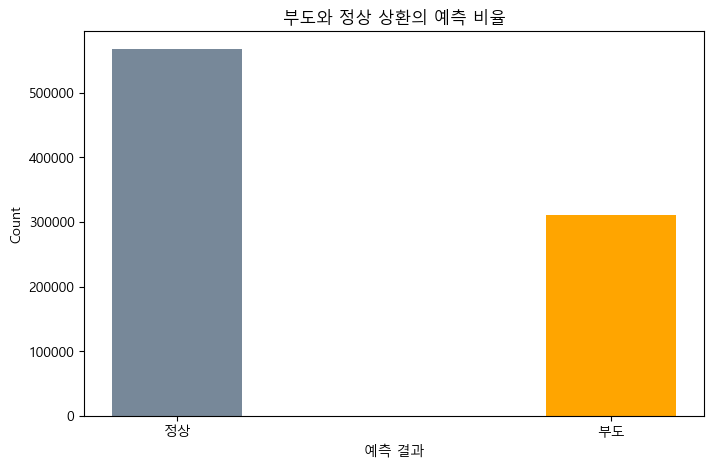

In [18]:
# 부도율 시각화
bar_prediction = result.groupby('default_prediction').size().reset_index(name='default_prediction_count')
display(bar_prediction)

colors = ['lightslategray', 'orange']

plt.figure(figsize=(8,5))

plt.bar(
    bar_prediction['default_prediction'],
    bar_prediction['default_prediction_count'],
    color=colors,
    width=0.3
)

plt.xticks([0,1], ['정상', '부도'])
plt.xlabel("예측 결과")
plt.ylabel("Count")

plt.title('부도와 정상 상환의 예측 비율')

plt.show()

In [19]:
# 위험도 등급별 도수
risk_count = result.groupby('risk_grade').size().reset_index(name='count')
display(risk_count)

,risk_grade,count
0,Low Risk,439135
1,Medium Risk,263481
2,High Risk,175654


,risk_grade,expected_loss_mean
0,Low Risk,1576.414143
1,Medium Risk,3180.608468
2,High Risk,4612.791377


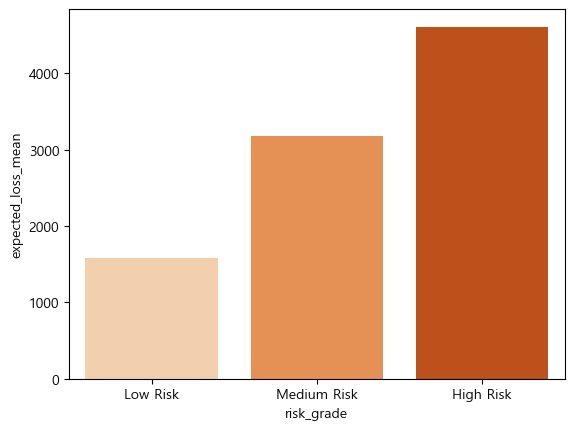

In [20]:
# 차주 1인당 평균 손실
risk_loss = result.groupby('risk_grade')['expected_loss'].mean().reset_index(name='expected_loss_mean')
display(risk_loss)

sns.barplot(data=risk_loss,
            x='risk_grade',
            y='expected_loss_mean',
            palette='Oranges')
plt.show()

In [29]:
# 손익율 계산을 위한 예측값과 손실액, 이익의 합 데이터프레임 뽑기

# 지수 표시 제거
pd.options.display.float_format = '{:,.0f}'.format

# 예상 손실액 합
expected_loss_sum = result.groupby('default_prediction')[['expected_loss', 'expected_return']].sum().reset_index()

display(expected_loss_sum)

# 손실 방지율 구하기
loss_no_per = (expected_loss_sum['expected_loss'].sum() - expected_loss_sum.loc[expected_loss_sum['default_prediction'] == 1, 'expected_loss'].sum()) / expected_loss_sum['expected_loss'].sum()
print(f'손실 방지율 : {loss_no_per:.0%}')

,default_prediction,expected_loss,expected_return
0,0,"1,057,479,551","248,349,356"
1,1,"1,283,064,230","151,937,029"


손실 방지율 : 45%
